# EDA - Explorando os Resultados do Stack Ensemble

Depois de gerar as previsões de todos os modelos base e do stack (regressão logística) nos notebooks anteriores (`stack_ensemble.ipynb`, `meta-dataset.ipynb`, etc.), esse notebook aqui é só pra **entender melhor o que está acontecendo por trás dos números**.

A ideia não é treinar nada novo, e sim juntar tudo que já foi gerado (previsões, probabilidades e erro de cada modelo, jogo a jogo) numa tabela só e investigar 3 perguntas:

1. **Os modelos base erram nos mesmos jogos ou em jogos diferentes?** Se todo mundo erra igual, o stack não tem muito o que aprender/combinar.
2. **As probabilidades que os modelos entregam são confiáveis?** Ou seja, quando um modelo diz "70% de chance de vitória", isso realmente acontece perto de 70% das vezes?
3. **O desempenho do stack se comporta igual do início ao fim da temporada?** Como o meta-modelo usa janela incremental, ele começa treinando com poucos exemplos — então faz sentido perguntar se isso prejudica o começo da temporada.

No final, dou uma olhada em como os coeficientes da regressão logística (o peso que ela dá pra cada modelo base) mudam conforme ela vai vendo mais jogos.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score
from sklearn.calibration import calibration_curve
from itertools import combinations

sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE    = sns.color_palette('tab10', 5)
STACK_COR  = '#e63946'

FEATURES = ['prob_svm', 'prob_knn', 'prob_extra_trees', 'prob_regressao_logistica', 'prob_lightgbm']
MODELOS  = ['svm', 'knn', 'extra_trees', 'regressao_logistica', 'lightgbm']
LABELS   = ['SVM', 'KNN', 'Extra Trees', 'Reg. Logística', 'LightGBM']
JANELAS  = [5, 10, 15]
TARGET   = 'Resultado Real'

BASE       = os.path.abspath(os.path.join('..'))
DIR_STACK  = os.path.join(BASE, 'results', 'experimento_04_stack')
DIR_DET    = os.path.join(BASE, 'results', 'experimento_03_detalhado')

## Carregamento e merge dos dados

Aqui eu junto tudo que preciso numa tabela só (`df_all`):

- o `meta_dataset_stack.csv`, que já tem as probabilidades dos 5 modelos base e o `Resultado Real` de cada jogo
- o `stack_ensemble_predicoes.csv`, com a previsão final do stack e a probabilidade que ele deu pra classe 1
- e, pra cada um dos 5 modelos base, o CSV detalhado do experimento 03 (`{modelo}_experimento_03_predicoes_detalhadas.csv`), de onde pego a previsão (`Previsao`) de cada um

O merge é feito por `Janela Incremental`, `Temporada` e `Ordem Jogo Temporada`  essas 3 colunas juntas identificam um jogo único, então garantem que estou comparando a previsão de todo mundo pro **mesmo jogo**.

No final, crio uma coluna `erro_{modelo}` pra cada modelo (1 quando ele errou, 0 quando acertou). Essas colunas de erro são a base de quase toda a análise de diversidade que vem a seguir.

In [4]:
df_meta = pd.read_csv(os.path.join(DIR_STACK, 'meta_dataset_stack.csv'))

df_stack_pred = pd.read_csv(os.path.join(DIR_STACK, 'stack_ensemble_predicoes.csv'))
df_stack_pred = df_stack_pred.rename(columns={
    'Previsao':              'pred_stack',
    'Probabilidade Classe 1':'prob_stack'
})

df_all = df_meta.copy()

for m in MODELOS:
    path = os.path.join(DIR_DET, f'{m}_experimento_03_predicoes_detalhadas.csv')
    df_m = pd.read_csv(path)[['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada', 'Previsao']]
    df_m = df_m.rename(columns={'Previsao': f'pred_{m}'})
    df_all = df_all.merge(df_m, on=['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada'], how='left')

df_all = df_all.merge(
    df_stack_pred[['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada', 'pred_stack', 'prob_stack']],
    on=['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada'],
    how='left'
)

for m in MODELOS:
    df_all[f'erro_{m}'] = (df_all[f'pred_{m}'] != df_all[TARGET]).astype(float)
df_all['erro_stack'] = (df_all['pred_stack'] != df_all[TARGET]).astype(float)

print(f'Shape total: {df_all.shape}')
df_all.head(3)

Shape total: (10740, 22)


,Janela Incremental,Temporada,Ordem Jogo Temporada,Resultado Real,prob_svm,prob_knn,prob_extra_trees,prob_regressao_logistica,prob_lightgbm,pred_svm,...,pred_regressao_logistica,pred_lightgbm,pred_stack,prob_stack,erro_svm,erro_knn,erro_extra_trees,erro_regressao_logistica,erro_lightgbm,erro_stack
0,5,2008-2009,1,1,0.733335,0.666667,0.800000,0.799964,0.800000,1,...,1,1,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
1,5,2008-2009,2,0,0.769852,0.666667,0.833333,0.833331,0.833333,1,...,1,1,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0
2,5,2008-2009,3,0,0.238587,0.333333,0.097143,0.535707,0.600000,0,...,1,1,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0


Aqui calculo a correlação entre as colunas de erro (`erro_svm`, `erro_knn`, etc.) de cada par de modelos, separado por janela incremental.

O que eu quero ver resumidamente: Valores **altos (perto de 1)** indicam que os dois modelos erram basicamente nos mesmos jogos, então juntar os dois no stack não ajuda muito.

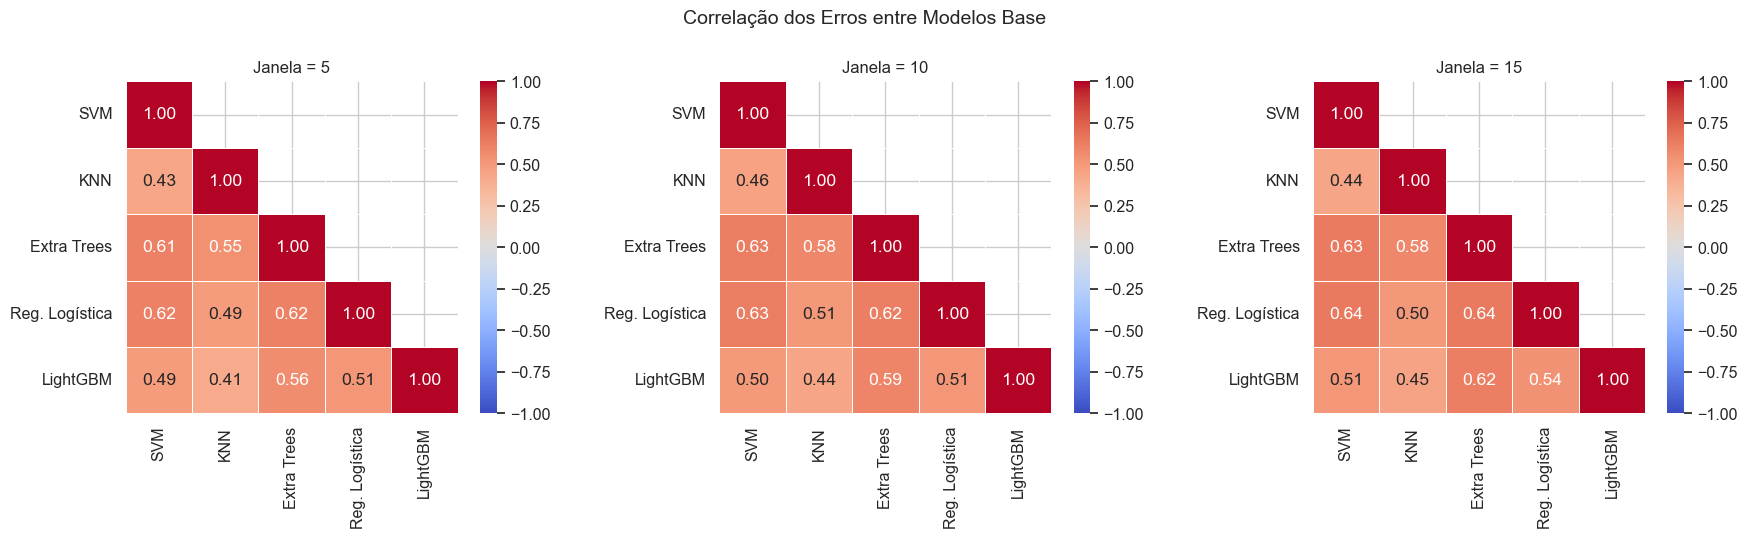

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, janela in zip(axes, JANELAS):
    cols_erro = [f'erro_{m}' for m in MODELOS]
    df_j = df_all[df_all['Janela Incremental'] == janela].dropna(subset=cols_erro)
    erros = df_j[cols_erro].copy()
    erros.columns = LABELS
    corr = erros.corr()

    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(
        corr, ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', vmin=-1, vmax=1,
        linewidths=0.5, square=True,
        mask=mask
    )
    ax.set_title(f'Janela = {janela}', fontsize=12)

fig.suptitle('Correlação dos Erros entre Modelos Base', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Aqui eu testo a hipótese do "cold start" de forma mais direta: separo os jogos em dois grupos — os primeiros `CORTE = 20` jogos depois da janela inicial, e o restante da temporada — e comparo a acurácia de cada modelo (incluindo o stack) nesses dois grupos.

A tabela no final mostra a diferença (`Demais jogos - Primeiros jogos`) pra cada modelo e janela. Diferença positiva confirma que o modelo (ou o stack) realmente performa pior no início, quando tem menos dado de treino disponível.

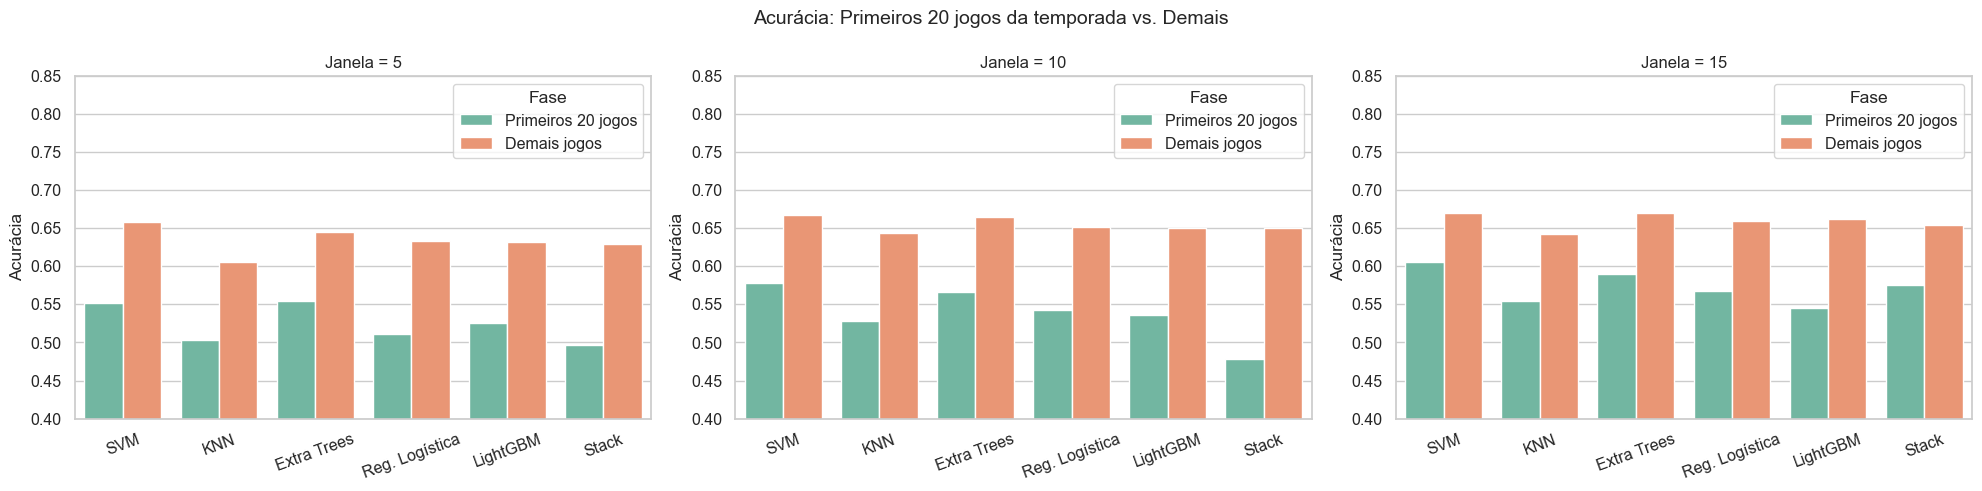

   Janela         Modelo  Demais jogos  Primeiros 20 jogos  Diferença
Janela 10    Extra Trees        0.6646              0.5667     0.0979
Janela 10            KNN        0.6434              0.5286     0.1148
Janela 10       LightGBM        0.6509              0.5357     0.1152
Janela 10 Reg. Logística        0.6522              0.5429     0.1093
Janela 10            SVM        0.6671              0.5786     0.0885
Janela 10          Stack        0.6506              0.4786     0.1720
Janela 15    Extra Trees        0.6695              0.5898     0.0797
Janela 15            KNN        0.6421              0.5551     0.0870
Janela 15       LightGBM        0.6623              0.5449     0.1174
Janela 15 Reg. Logística        0.6593              0.5673     0.0920
Janela 15            SVM        0.6699              0.6061     0.0638
Janela 15          Stack        0.6543              0.5750     0.0793
 Janela 5    Extra Trees        0.6455              0.5543     0.0912
 Janela 5           

In [14]:
CORTE = 20
records_fase = []

for janela in JANELAS:
    df_j = df_all[df_all['Janela Incremental'] == janela]
    limite_inicio = janela + CORTE

    for m, label in zip(MODELOS + ['stack'], LABELS + ['Stack']):
        pred_col = f'pred_{m}' if m != 'stack' else 'pred_stack'

        for fase, mask in [
            (f'Primeiros {CORTE} jogos', df_j['Ordem Jogo Temporada'] <= limite_inicio),
            ('Demais jogos',             df_j['Ordem Jogo Temporada'] >  limite_inicio)
        ]:
            s = df_j.loc[mask].dropna(subset=[pred_col])
            if len(s) == 0:
                continue
            acc = accuracy_score(s[TARGET], s[pred_col])
            records_fase.append({
                'Janela': f'Janela {janela}',
                'Modelo': label,
                'Fase': fase,
                'Acurácia': round(acc, 4),
                'N': len(s)
            })

df_fase = pd.DataFrame(records_fase)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ordem_modelos = LABELS + ['Stack']
cores_fase    = sns.color_palette('Set2', 2)

for ax, janela in zip(axes, JANELAS):
    sub = df_fase[df_fase['Janela'] == f'Janela {janela}']
    sns.barplot(
        data=sub, x='Modelo', y='Acurácia',
        hue='Fase', palette=cores_fase,
        order=ordem_modelos, ax=ax
    )
    ax.set_title(f'Janela = {janela}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylim(0.40, 0.85)
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

fig.suptitle(f'Acurácia: Primeiros {CORTE} jogos da temporada vs. Demais', fontsize=14)
plt.tight_layout()
plt.show()

tabela_pivot = df_fase.pivot_table(
    index=['Janela', 'Modelo'], columns='Fase',
    values='Acurácia', aggfunc='first'
).reset_index()

col_inicio = f'Primeiros {CORTE} jogos'
tabela_pivot['Diferença'] = (tabela_pivot['Demais jogos'] - tabela_pivot[col_inicio]).round(4)
print(tabela_pivot.to_string(index=False))

## Confiança vs. Acerto: quando o modelo "aposta forte", ele acerta?

eu quero olhar o quanto a **confiança** do modelo se traduz em acerto de verdade.



In [6]:
bins_conf   = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0001]
labels_conf = ['50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

for janela in JANELAS:
    print('=' * 78)
    print(f'CONFIANCA vs ACERTO  |  Janela = {janela}')
    print('=' * 78)

    linhas = []
    for m, label in zip(MODELOS, LABELS):
        sub = df_all[df_all['Janela Incremental'] == janela][[f'prob_{m}', f'pred_{m}', TARGET]].dropna().copy()
        sub['conf']    = np.maximum(sub[f'prob_{m}'], 1 - sub[f'prob_{m}'])
        sub['acertou'] = (sub[f'pred_{m}'] == sub[TARGET]).astype(int)
        sub['faixa']   = pd.cut(sub['conf'], bins=bins_conf, labels=labels_conf, right=False)

        for faixa in labels_conf:
            s = sub[sub['faixa'] == faixa]
            n = len(s)
            if n == 0:
                continue
            acertos = int(s['acertou'].sum())
            erros   = n - acertos
            linhas.append({
                'Modelo':    label,
                'Confianca': faixa,
                'Jogos':     n,
                'Acertos':   acertos,
                'Erros':     erros,
                '% Acerto':  f'{acertos / n * 100:.1f}%'
            })

    tabela = pd.DataFrame(linhas)
    print(tabela.to_string(index=False))
    print()

CONFIANCA vs ACERTO  |  Janela = 5
        Modelo Confianca  Jogos  Acertos  Erros % Acerto
           SVM    50-60%   1526      870    656    57.0%
           SVM    60-70%   1071      730    341    68.2%
           SVM    70-80%    687      475    212    69.1%
           SVM    80-90%    279      216     63    77.4%
           SVM   90-100%     87       73     14    83.9%
           KNN    50-60%    799      439    360    54.9%
           KNN    60-70%   1398      772    626    55.2%
           KNN    70-80%    503      304    199    60.4%
           KNN    80-90%    504      343    161    68.1%
           KNN   90-100%    446      318    128    71.3%
   Extra Trees    50-60%   1410      770    640    54.6%
   Extra Trees    60-70%   1168      765    403    65.5%
   Extra Trees    70-80%    715      526    189    73.6%
   Extra Trees    80-90%    276      213     63    77.2%
   Extra Trees   90-100%     81       50     31    61.7%
Reg. Logística    50-60%   1113      593    520    53